# Market Analysis - Santa Clara County

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

#from EDA_combined import listoffice_summary

### 1. Load the data

In [140]:
sold_filepath = "/Users/cynthiagao/PycharmProjects/IDX Exchange Internship/sold_cleaned.csv"
listings_filepath = "/Users/cynthiagao/PycharmProjects/IDX Exchange Internship/listings_cleaned.csv"

sold = pd.read_csv(sold_filepath, low_memory=False)
listings = pd.read_csv(listings_filepath, low_memory=False)

listings_santaclara = listings[listings["CountyOrParish"] == "Santa Clara"].copy()
sold_santaclara = sold[sold["CountyOrParish"] == "Santa Clara"].copy()

pd.set_option("display.max_columns", None)

In [141]:
sold_santaclara.to_csv("sold_santaclara.csv", index=False)

In [142]:
listings_santaclara.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,AssociationFeeFrequency,ListingKeyNumeric,MLSAreaMajor,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BuyerAgencyCompensationType,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,BuyerAgencyCompensation,BedroomsTotal,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate,StateOrProvince,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,year_month,rate_30yr_fixed,close_year,close_month,close_day,close_yrmoday,close_yrmo,contractstatuschange_year,contractstatuschange_month,contractstatuschange_day,contractstatuschange_yrmoday,contractstatuschange_yrmo,purchasecontract_year,purchasecontract_month,purchasecontract_day,purchasecontract_yrmoday,purchasecontract_yrmo,listingcontract_year,listingcontract_month,listingcontract_day,listingcontract_yrmoday,listingcontract_yrmo,ClosePrice_outlier,ListPrice_outlier,OriginalListPrice_outlier,LivingArea_outlier,LotSizeAcres_outlier,BedroomsTotal_outlier,BathroomsTotalInteger_outlier,DaysOnMarket_outlier,YearBuilt_outlier,PriceRatio,Price_per_sqft,DOM_bucket,Listing_to_Contract_Days,Contract_to_Close_Days
773,1299000.0,1059828855,lindsey@lindsey-peters.com,2024-03-04,1505000.0,Lindsey,Peters,NaN,NaN,1585 Greenwood Way,Residential,1190.0,1299000.0,6,Everhome,Compass,NaN,Lindsey Peters,NaN,NaN,CCBE-MLL5066983,Shilpa,Joshi,Monthly,1059828855,NaN,Santa Clara,Closed,NaN,1,2.0,SingleFamilyResidence,0.1148,STARLIGHT PINES,MLSListings,1967.0,Item1,1585.0,41048920,2.0,Milpitas,2.5,3.0,2024-03-04,2024-02-06,2024-01-31,CA,NaN,1,1.0,NaN,One,5000.0,NaN,0,2.0,NaN,95035,30.0,5000.0,2024-01,6.6425,2024.0,3.0,4.0,20240304.0,202403.0,2024.0,3.0,4.0,20240304.0,202403.0,2024.0,2.0,6.0,20240206.0,202402.0,2024,1,31,20240131,202401,False,False,False,False,False,False,False,False,False,1.158584,1264.705882,0-7,6 days,27 days
798,2298000.0,1059819652,alexandrazhouca@gmail.com,2024-02-29,2583000.0,Alexandra,Zhou,NaN,NaN,563 Alberta Avenue,Residential,1621.0,2298000.0,7,Morgan Real Estate,Intero Real Estate Services,NaN,Alexandra Zhou,NaN,NaN,ML5095347,Eugene,Hong,NaN,1059819652,699 - Not Defined,Santa Clara,Closed,NaN,1,2.0,SingleFamilyResidence,0.0900,NaN,MLSListings,2006.0,Item1,563.0,ML81953038,3.0,Sunnyvale,2.5,4.0,2024-02-29,2024-02-07,2024-01-31,CA,NaN,1,NaN,NaN,NaN,3920.0,NaN,0,2.0,Other,94087,NaN,3920.0,2024-01,6.6425,2024.0,2.0,29.0,20240229.0,202402.0,2024.0,2.0,29.0,20240229.0,202402.0,2024.0,2.0,7.0,20240207.0,202402.0,2024,1,31,20240131,202401,True,False,False,False,False,False,False,False,False,1.124021,1593.460827,0-7,7 days,22 days
822,1498000.0,1059654725,ryan.gowdy@theagencyre.com,2024-02-22,1860000.0,Ryan,Gowdy,NaN,NaN,1359 Canton Drive,Residential,1867.0,1498000.0,7,The Agency,The Agency,NaN,Ryan Gowdy,NaN,NaN,ML5090472,Brett,Weitzmann,NaN,1059654725,699 - Not Defined,Santa Clara,Closed,NaN,1,2.0,SingleFamilyResidence,0.3700,NaN,MLSListings,1966.0,Item1,1359.0,ML81953033,3.0,Milpitas,2.5,4.0,2024-02-22,2024-02-07,2024-01-31,CA,NaN,1,NaN,NaN,NaN,16117.0,NaN,0,2.0,Other,95035,NaN,16117.0,2024-01,6.6425,2024.0,2.0,22.0,20240222.0,202402.0,2024.0,2.0,22.0,20240222.0,202402.0,2024.0,2.0,7.0,20240207.0,202402.0,2024,1,31,20240131,202401,False,False,False,False,False,False,False,False,False,1.241656,996.250670,0-7,7 days,15 days
850,965000.0,1059617257,abaker7@gmail.com,2024-03-08,1152000.0,Annie Baker,Cleaver,NaN,NaN,130 Monte Villa Court,Residential,1188.0,965000.0,7,Alta Realty Group CA,NaN,NaN,Annie Baker Cleaver,NaN,

In [143]:
listings_santaclara.shape

(4856, 96)

In [144]:
sold_santaclara.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,AssociationFeeFrequency,ListingKeyNumeric,MLSAreaMajor,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,BedroomsTotal,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate,StateOrProvince,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled,year_month,rate_30yr_fixed,close_year,close_month,close_day,close_yrmoday,close_yrmo,contractstatuschange_year,contractstatuschange_month,contractstatuschange_day,contractstatuschange_yrmoday,contractstatuschange_yrmo,purchasecontract_year,purchasecontract_month,purchasecontract_day,purchasecontract_yrmoday,purchasecontract_yrmo,listingcontract_year,listingcontract_month,listingcontract_day,listingcontract_yrmoday,listingcontract_yrmo,ClosePrice_outlier,ListPrice_outlier,OriginalListPrice_outlier,LivingArea_outlier,LotSizeAcres_outlier,BedroomsTotal_outlier,BathroomsTotalInteger_outlier,DaysOnMarket_outlier,YearBuilt_outlier,PriceRatio,Price_per_sqft,DOM_bucket,Listing_to_Contract_Days,Contract_to_Close_Days,Market_Condition,Price_Reduction,Was_Reduced,Price_Tier
15,Mlslistings,Mlslistings,NaN,0,0,998000.0,1059595260,ryan.gowdy@theagencyre.com,2024-01-31,1030000.0,Ryan,Gowdy,NaN,NaN,1375 Milton Way,Residential,1053.0,998000.0,0,The Agency,Compass,NaN,Ryan Gowdy,NaN,NaN,ML5067420,Ashley,Mateo,NaN,1059595260,699 - Not Defined,Santa Clara,Closed,NaN,0,1.0,SingleFamilyResidence,0.1400,NaN,Mlslistings,1939.0,1375.0,ML81952931,1.0,San Jose,2.0,2024-01-31,2024-01-31,2024-01-31,CA,NaN,1,NaN,NaN,NaN,6098.0,NaN,0,1.0,San Jose Unified,95125,NaN,6098.0,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN,2024-01,6.6425,2024,1,31,20240131,202401,2024.0,1.0,31.0,20240131.0,202401.0,2024.0,1.0,31.0,20240131.0,202401.0,2024.0,1.0,31.0,20240131.0,202401.0,False,False,False,False,False,False,False,False,False,1.032064,978.157645,NaN,0 days,0 days,1,0.0,0,1M-2M
19,Mlslistings,Mlslistings,"Carpet,Tile",0,0,1688000.0,1059545289,bonafede@compass.com,2024-01-30,1595000.0,NaN,Bonafede Team,NaN,NaN,6496 Sproul Court,Residential,1531.0,1688000.0,0,Compass,Compass,NaN,Bonafede Team,NaN,NaN,ML5088850,Radney,Toomasian,NaN,1059545289,699 - Not Defined,Santa Clara,Closed,NaN,1,2.0,SingleFamilyResidence,0.2000,NaN,Mlslistings,1976.0,6496.0,ML81952829,2.0,San Jose,3.0,2024-01-30,2024-01-30,2024-01-30,CA,NaN,1,NaN,NaN,NaN,8712.0,NaN,0,2.0,San Jose Unified,95120,NaN,8712.0,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN,2024-01,6.6425,2024,1,30,20240130,202401,2024.0,1.0,30.0,20240130.0,202401.0,2024.0,1.0,30.0,20240130.0,202401.0,2024.0,1.0,30.0,20240130.0,202401.0,False,False,False,False,False,False,False,False,False,0.944905,1041.802743,NaN,0 days,0 days,0,0.0,0,1M-2M
45,Mlslistings,Mlslistings,"Tile,Wood",0,0,2488950.0,1058682864,yvonne@yvonneyanghomes.com,2024-01-31,3060000.0,Yvonne,Yang,NaN,NaN,1149 London Avenue,Residential,2035.0,2488950.0,5,Compass,Compass,NaN,Yvonne Yang,NaN,NaN,ML5099368,Helen,Zhong,NaN,1058682864,699 - Not Defined,Santa Clara,Closed,Laurelwood,1,2.0,SingleFamilyResidence,0.1488,NaN,Mlslistings,1955.0,1149.0,ML81947062,4.0,Sunnyvale,4.0,2024-01-31,2024-01-29,2024-01-24,CA,Marian A. Peterson,1,NaN,Adrian Wilcox,NaN,6480.0,NaN,0,2.0,Other,94087,NaN,6480.0,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN,2024-01,6.6425,2024,1,31,20240131,202401,2024.0

In [145]:
sold_santaclara.shape

(11403, 109)

In [146]:
# Color Code for Seaborn Graphs

color = "#BD6877"

#### What are the median and average close prices?

In [147]:
print(f"Median Close Price = ${sold_santaclara['ClosePrice'].median():.2f}")

print(f"Average Close Price = ${sold_santaclara['ClosePrice'].mean():.2f}")

Median Close Price = $1610000.00
Average Close Price = $1684610.02


#### What percentage of homes sold above vs. below list price?

In [148]:
percent_sold_above = (sum(sold_santaclara['ClosePrice'] > sold_santaclara['ListPrice']) / len(sold_santaclara))*100

percent_sold_below = (sum(sold_santaclara['ClosePrice'] < sold_santaclara['ListPrice']) / len(sold_santaclara))*100

print(f"Percent sold above list price {percent_sold_above:.2f}%")
print(f"Percent sold below list price {percent_sold_below:.2f}%")


Percent sold above list price 69.03%
Percent sold below list price 24.43%


#### What does the Days on Market distribution look like?

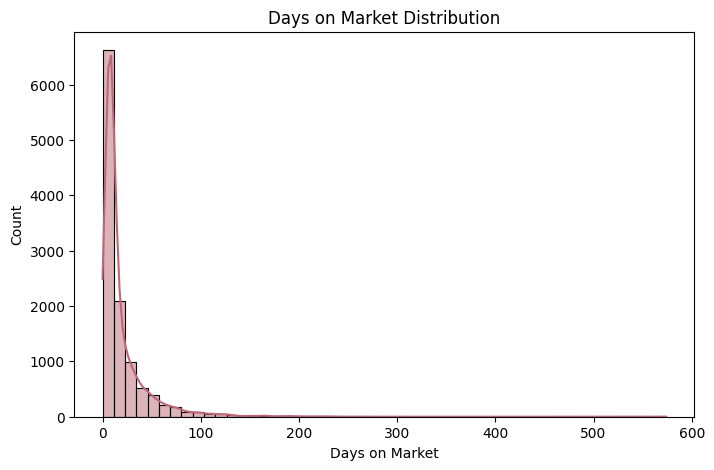

In [149]:
plt.figure(figsize=(8,5))
sns.histplot(sold_santaclara["DaysOnMarket"], bins = 50, kde = True, color=color)
plt.title("Days on Market Distribution")
plt.xlabel("Days on Market")
plt.ylabel("Count")
plt.show()

### Summary Statistics

#### Overall Market Snapshot

In [150]:
market_snapshot = sold_santaclara[[
    "ListPrice", "OriginalListPrice", "ClosePrice", "PriceRatio",
    "Price_per_sqft", "LivingArea", "DaysOnMarket"
]].describe(percentiles=[0.25, 0.5, 0.75]).T

market_snapshot

,count,mean,std,min,25%,50%,75%,max
ListPrice,11403.0,1.585238e+06,533995.964901,345000.000000,1.199000e+06,1.499888e+06,1.900000e+06,3.138888e+06
OriginalListPrice,11403.0,1.596405e+06,535983.128605,315000.000000,1.199000e+06,1.500000e+06,1.950000e+06,2.895000e+06
ClosePrice,11403.0,1.684610e+06,599831.888752,300000.000000,1.250000e+06,1.610000e+06,2.070000e+06,3.800000e+06
PriceRatio,11403.0,1.053013e+00,0.107136,0.579372,9.866500e-01,1.037736e+00,1.112009e+00,2.186666e+00
Price_per_sqft,11403.0,1.053822e+03,392.372948,213.872832,7.809340e+02,9.876543e+02,1.241728e+03,3.369474e+03
LivingArea,11403.0,1.668238e+03,514.250607,784.000000,1.284000e+03,1.580000e+03,1.958000e+03,3.649000e+03
DaysOnMarket,11403.0,1.932912e+01,27.106134,0.000000,7.000000e+00,9.000000e+00,2.100000e+01,5.740000e+02


In [151]:
kpi_summary = {
    "Total Closed Sales": len(sold_santaclara),
    "Median Sold Price": sold_santaclara["ClosePrice"].median(),
    "Average Sold Price": sold_santaclara["ClosePrice"].mean(),
    "Median Price per Sq Ft": sold_santaclara["Price_per_sqft"].median(),
    "Median Days on Market": sold_santaclara["DaysOnMarket"].median(),
    "Average Sale-to-List Price Ratio": sold_santaclara["PriceRatio"].mean()
}

kpi_df = pd.DataFrame({
    "Metric": list(kpi_summary.keys()),
    "Value": list(kpi_summary.values())
})

def format_kpi(row):
    metric = row["Metric"]
    value = row["Value"]

    if metric in ["Median Sold Price", "Average Sold Price", "Median Price per Sq Ft"]:
        return f"${value:,.2f}"
    elif metric == "Average Sale-to-List Price Ratio":
        return f"{value:.2f}"
    elif metric in ["Total Closed Sales", "Median Days on Market"]:
        return f"{value:,.0f}"
    else:
        return value

kpi_df["Value"] = kpi_df.apply(format_kpi, axis=1)

kpi_df

,Metric,Value
0,Total Closed Sales,"11,403"
1,Median Sold Price,"$1,610,000.00"
2,Average Sold Price,"$1,684,610.02"
3,Median Price per Sq Ft,$987.65
4,Median Days on Market,9
5,Average Sale-to-List Price Ratio,1.05


In [152]:
print(f"Percent of listings with PriceRatio >= 1: {sold_santaclara['Market_Condition'].mean() * 100:.2f}%")

Percent of listings with PriceRatio >= 1: 71.42%


#### By City within Santa Clara County

In [153]:
# How many different cities are in Santa Clara County?

print(f"Number of Cities = {sold_santaclara["City"].dropna().nunique()}")

sorted(sold_santaclara["City"].dropna().unique())

Number of Cities = 18


['Alviso',
 'Campbell',
 'Cupertino',
 'Gilroy',
 'Los Altos',
 'Los Altos Hills',
 'Los Gatos',
 'Milpitas',
 'Monte Sereno',
 'Morgan Hill',
 'Mountain View',
 'Palo Alto',
 'San Jose',
 'San Martin',
 'Santa Clara',
 'Saratoga',
 'Stanford',
 'Sunnyvale']

In [154]:
city_summary = (
    sold_santaclara.groupby("City", dropna=False).agg(
        ListingCount = ("ListPrice", "size"),
        MedianListPrice = ("ListPrice", "median"),
        MedianPricePerSqFt = ("Price_per_sqft", "median"),
        MedianDaysOnMarket = ("DaysOnMarket", "median"),
        AvgPriceRatio = ("PriceRatio", "mean")
    )
    .sort_values("ListingCount", ascending=False)
)

city_summary.head(10)

,ListingCount,MedianListPrice,MedianPricePerSqFt,MedianDaysOnMarket,AvgPriceRatio
City,,,,,
San Jose,6617,1485000.0,957.446809,9.0,1.051743
Sunnyvale,843,1950000.0,1395.768834,8.0,1.096808
Santa Clara,762,1688944.0,1261.715934,8.0,1.089310
Morgan Hill,570,1299998.5,648.197685,12.5,1.000369
Gilroy,557,1095000.0,531.552018,16.0,0.996643
Milpitas,441,1399000.0,953.206239,10.0,1.057372
Mountain View,405,1920000.0,1305.334847,9.0,1.066658
Campbell,355,1789000.0,1172.839506,8.0,1.059670
Los Gatos,336,1869000.0,1145.371222,10.0,1.019253


#### By Property Subtype

In [155]:
subtype_summary = (
    sold_santaclara.groupby("PropertySubType", dropna=False).agg(
        ListingCount = ("ListPrice", "size"),
        MedianListPrice = ("ListPrice", "median"),
        MedianPricePerSqFt = ("Price_per_sqft", "median"),
        MedianDaysOnMarket = ("DaysOnMarket", "median"),
        AvgPriceRatio = ("PriceRatio", "mean")
    )
    .sort_values("ListingCount", ascending=False)
)

subtype_summary.head()

,ListingCount,MedianListPrice,MedianPricePerSqFt,MedianDaysOnMarket,AvgPriceRatio
PropertySubType,,,,,
SingleFamilyResidence,9446,1599000.0,1036.842367,9.0,1.059727
Townhouse,1298,1248000.0,835.405722,12.0,1.030997
Condominium,633,848000.0,711.030082,16.0,0.998965
NaN,21,1298888.0,889.328063,12.0,1.044842
Farm,2,1593950.0,1288.179040,7.5,1.066313


#### By Listing Office

In [156]:
top10_offices = sold_santaclara["ListOfficeName"].value_counts().head(10).index

listoffice_summary = (sold_santaclara[sold_santaclara["ListOfficeName"].isin(top10_offices)]
    .groupby("ListOfficeName", dropna=False).agg(
        ListingCount = ("ListPrice", "size"),
        MedianListPrice = ("ListPrice", "median"),
        MedianPricePerSqFt = ("Price_per_sqft", "median"),
        MedianDaysOnMarket = ("DaysOnMarket", "median"),
        AvgPriceRatio = ("PriceRatio", "mean")
    )
    .sort_values("ListingCount", ascending=False)
)

listoffice_summary

,ListingCount,MedianListPrice,MedianPricePerSqFt,MedianDaysOnMarket,AvgPriceRatio
ListOfficeName,,,,,
Compass,1614,1580000.0,1019.178163,8.0,1.063756
Intero Real Estate Services,1572,1500000.0,995.513969,9.0,1.063436
Coldwell Banker Realty,1449,1550000.0,1001.381215,8.0,1.056346
Christie's International Real Estate Sereno,586,1599000.0,1041.780905,8.0,1.056515
KW Bay Area Estates,338,1649475.0,1009.139142,9.0,1.046701
Keller Williams Realty-Silicon Valley,251,1649000.0,1115.044248,8.0,1.103424
Keller Williams Thrive,212,1524900.0,1073.926319,8.0,1.086887
eXp Realty of California Inc,179,1475000.0,921.553694,11.0,1.040083
Redfin,153,1399888.0,965.836711,12.0,1.032454


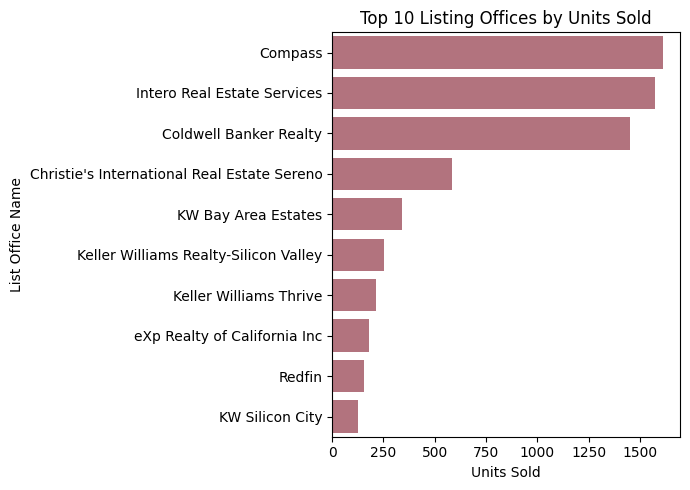

In [157]:
office_units = (
    sold_santaclara[sold_santaclara["ListOfficeName"].isin(top10_offices)]
    .groupby("ListOfficeName")
    .size()
    .reset_index(name="UnitsSold")
    .sort_values("UnitsSold", ascending=False))

plt.figure(figsize=(7, 5))
sns.barplot(data=office_units, x="UnitsSold", y="ListOfficeName", color=color)
plt.title("Top 10 Listing Offices by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("List Office Name")
plt.tight_layout()
plt.show()

#### Median List Price by City

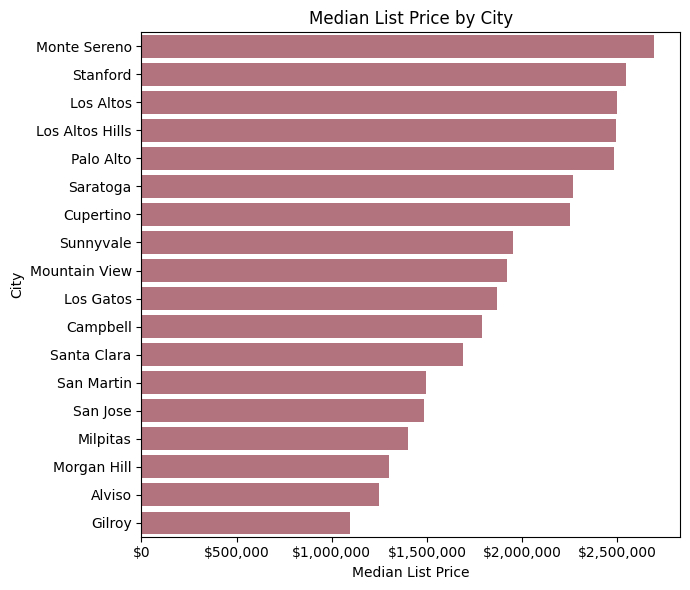

In [158]:
city_listprice = (sold_santaclara.groupby("City", as_index=False)["ListPrice"]
                .median().rename(columns={"ListPrice": "MedianListPrice"})
                .sort_values("MedianListPrice", ascending=False))

plt.figure(figsize=(7,6))
ax = sns.barplot(data = city_listprice, x = "MedianListPrice", y = "City", color=color)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))
plt.title("Median List Price by City")
plt.xlabel("Median List Price")
plt.ylabel("City")
plt.tight_layout()
plt.show()

#### Median Close Price by City

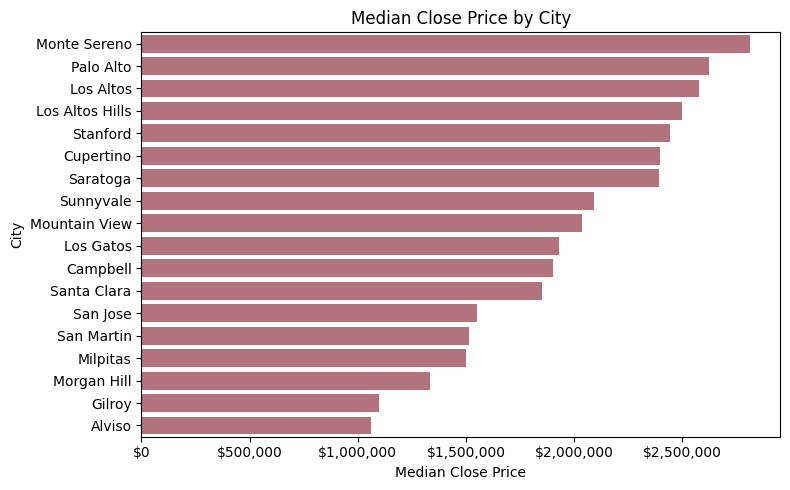

In [159]:
city_closeprice = (sold_santaclara.groupby("City", as_index=False)["ClosePrice"]
                .median().rename(columns={"ClosePrice": "MedianClosePrice"})
                .sort_values("MedianClosePrice", ascending=False))

plt.figure(figsize=(8,5))
ax = sns.barplot(data = city_closeprice, x = "MedianClosePrice", y = "City", color=color)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))
plt.title("Median Close Price by City")
plt.xlabel("Median Close Price")
plt.ylabel("City")
plt.tight_layout()
plt.show()

#### List Price Distribution

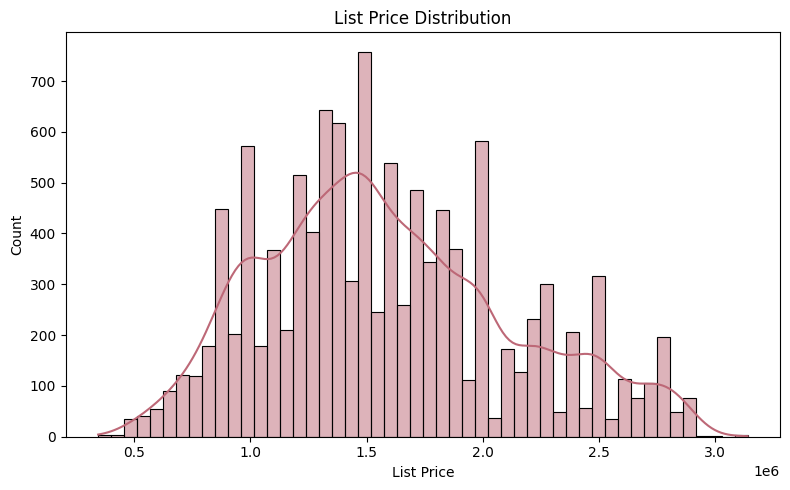

In [160]:
plt.figure(figsize=(8,5))
sns.histplot(sold_santaclara["ListPrice"], bins = 50, kde = True, color=color)
plt.title("List Price Distribution")
plt.xlabel("List Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### Monthly Median Close Price and Number of Sales Over Time

Waiting for May datasets before importing to my presentation slides

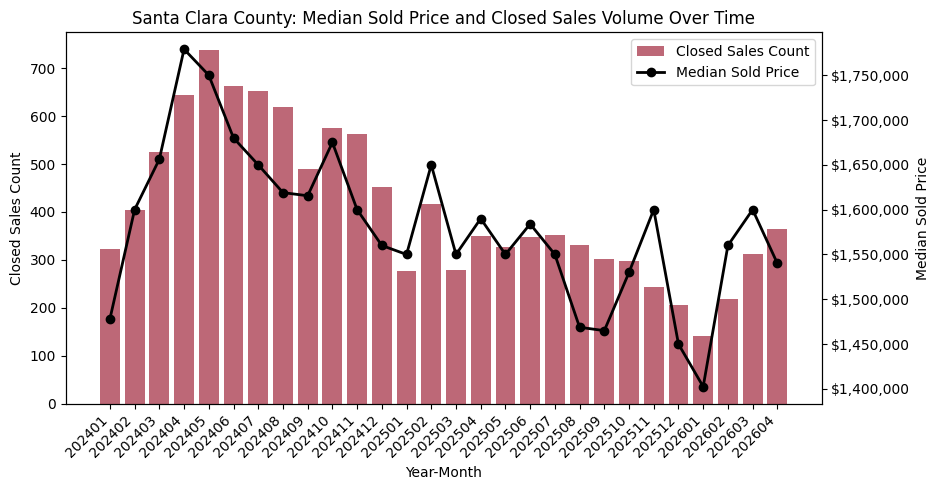

In [161]:
# Create monthly median sold price
monthly_price = (
    sold_santaclara.groupby("close_yrmo", as_index=False)["ClosePrice"]
    .median()
    .rename(columns={"ClosePrice": "MedianSoldPrice"}))

# Create monthly closed sales count
monthly_volume = (
    sold_santaclara.groupby("close_yrmo")
    .size()
    .reset_index(name="ClosedSalesCount"))

# Merge and sort
monthly_summary = monthly_price.merge(monthly_volume, on="close_yrmo")
monthly_summary = monthly_summary.sort_values("close_yrmo").reset_index(drop=True)

# Numeric x positions
x = np.arange(len(monthly_summary))

fig, ax1 = plt.subplots(figsize=(9.5, 5))

# Bars for volume
ax1.bar(x, monthly_summary["ClosedSalesCount"], color=color, label="Closed Sales Count")
ax1.set_ylabel("Closed Sales Count")
ax1.set_xlabel("Year-Month")
ax1.set_xticks(x)
ax1.set_xticklabels(monthly_summary["close_yrmo"], rotation=45, ha="right")

# Line for median sold price
ax2 = ax1.twinx()
ax2.plot(x, monthly_summary["MedianSoldPrice"], color="black", marker="o", linewidth=2, label="Median Sold Price")
ax2.set_ylabel("Median Sold Price")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"${y:,.0f}"))

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

plt.title("Santa Clara County: Median Sold Price and Closed Sales Volume Over Time")
plt.tight_layout()
plt.show()

#### Median Days on Market by City

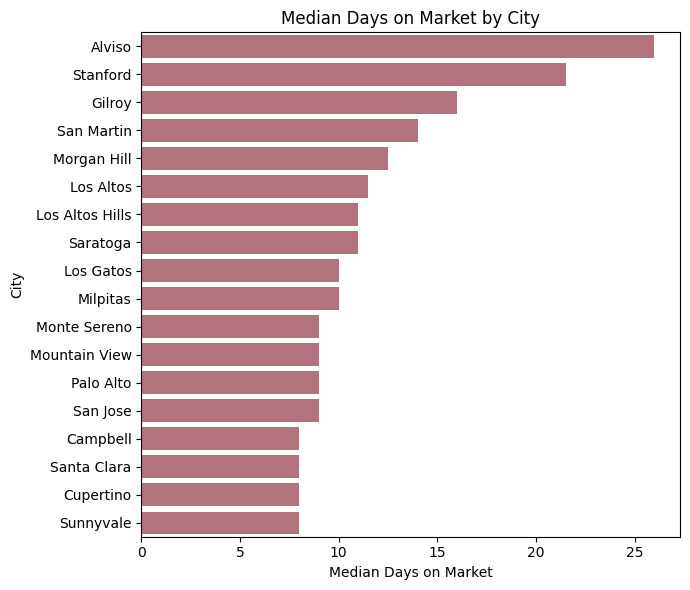

In [162]:
city_dom = (
    sold_santaclara.groupby("City", as_index=False)["DaysOnMarket"]
    .median()
    .rename(columns={"DaysOnMarket": "MedianDaysOnMarket"})
    .sort_values("MedianDaysOnMarket", ascending=False)
)

plt.figure(figsize=(7, 6))
sns.barplot(data=city_dom, x="MedianDaysOnMarket", y="City", color=color)
plt.title("Median Days on Market by City")
plt.xlabel("Median Days on Market")
plt.ylabel("City")
plt.tight_layout()
plt.show()

#### Median Price per SqFt by City

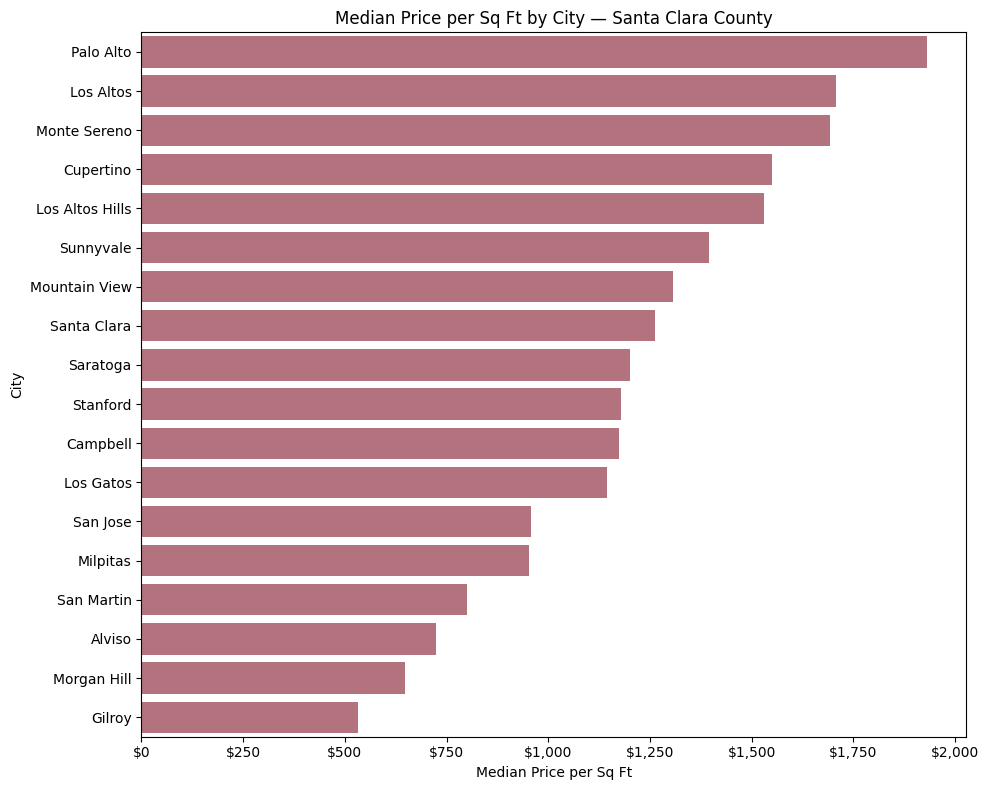

In [163]:
city_ppsf = (
    sold_santaclara.groupby("City", as_index=False)["Price_per_sqft"]
    .median()
    .rename(columns={"Price_per_sqft": "MedianPricePerSqFt"})
    .sort_values("MedianPricePerSqFt", ascending=False)
)

plt.figure(figsize=(10, 8))
ax = sns.barplot(data=city_ppsf, x="MedianPricePerSqFt", y="City", color=color)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))
plt.title("Median Price per Sq Ft by City — Santa Clara County")
plt.xlabel("Median Price per Sq Ft")
plt.ylabel("City")
plt.tight_layout()
plt.show()

#### Price per SqFt vs. Living Area Scatterplot

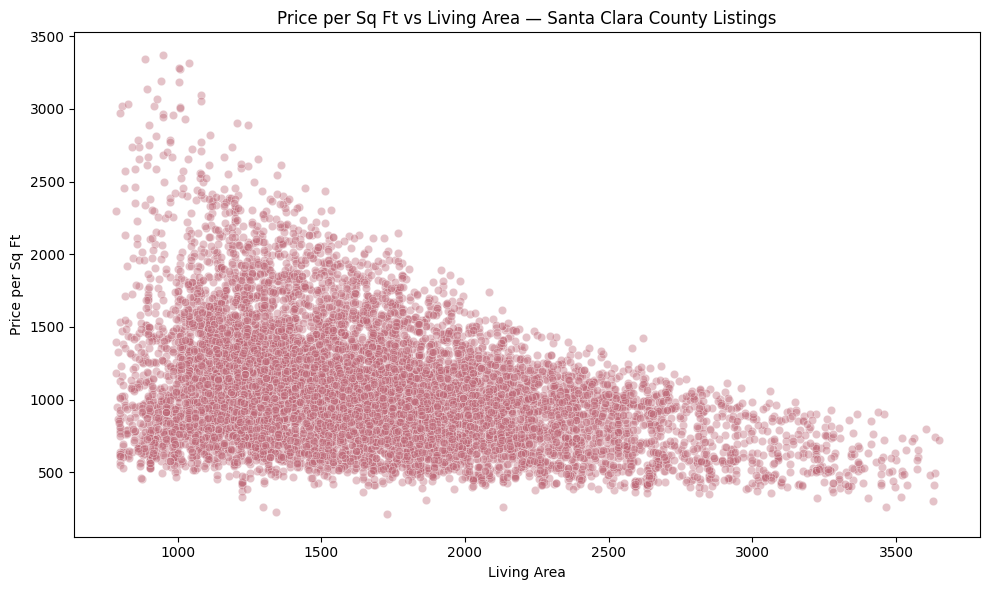

In [164]:
plot_df = sold_santaclara[
    sold_santaclara["Price_per_sqft"].notna() &
    sold_santaclara["LivingArea"].notna()
]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="LivingArea", y="Price_per_sqft", alpha=0.4, color=color)
plt.title("Price per Sq Ft vs Living Area — Santa Clara County Listings")
plt.xlabel("Living Area")
plt.ylabel("Price per Sq Ft")
plt.tight_layout()
plt.show()